In [51]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
print(sys.path)
#sys.path.append('//Users/milliema/Documents/Year5/masterProject/toyBloch/examples')
# path_to_remove = sys.path[-1]
# sys.path.remove(path_to_remove)
# print(sys.path)
import sequence
print(sequence.__file__)
import os
print(os.getcwd())




import simulate.kernels
from simulate import BlochDispatcher

['/Users/milliema/miniconda3/envs/bloch_envx/lib/python312.zip', '/Users/milliema/miniconda3/envs/bloch_envx/lib/python3.12', '/Users/milliema/miniconda3/envs/bloch_envx/lib/python3.12/lib-dynload', '', '/Users/milliema/miniconda3/envs/bloch_envx/lib/python3.12/site-packages']
//Users/milliema/Documents/Year5/masterProject/toyBloch/sequence/__init__.py
/Users/milliema/Documents/Year5/masterProject/toyBloch/examples


We start by defining the time step of the simulation as 10us (equivalent to 0.01ms). 

Then, we define a hyperbolic secant RF pulse with a duration of 5000us, a scaling factor on the frequency sweep of 5, and a spectral bandwidth of 2400Hz.

In [ ]:
dt = 10
pulse = sequence.rf.hyperbolic_secant(5000, mu=5, bandwidth=2400, dt=dt)
print(type(pulse))
print(dir(pulse))


<class 'sequence.rf.RFPulse'>
['__add__', '__class__', '__copy__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__sub__', '__subclasshook__', '__weakref__', '_current_times', '_normalized_waveform', '_times', '_waveform', 'amplitude', 'append', 'asymmetry', 'display', 'dt', 'duration', 'energy', 'get_bloch_siegert_shift', 'get_fwhm', 'get_optimal_amplitude', 'is_phase_modulated', 'magnitude', 'n', 'phase', 'resample', 'times', 'transmit_frequency', 'transmit_phase', 'waveform', 'zero_pad']


In order to produce an inversion, we need to determine the B1 amplitude required. This is done using the set_optimal_amplitude function, which all RF pulses possess. 

Its arguments are the desired flip angle, the off-resonance frequency range to optimise over, and the range of allowed B1 amplitudes. The last two arguments default to 5000Hz (a range of -2500 to 2500Hz) and 0 to 30uT.

The function performs an initial linear search over the range of B1 values. This is then followed by an adaptive random search of a narrowing section of the B1 range. The cost is defined by the least squares difference between the theoretical longitudinal and transverse magnetisation from the simulated magnetisation for each B1 amplitude tested. There is also a minor penalty for large B1 amplitudes, promoting lower B1 amplitudes for adiabatic pulses.

After this optimisation process, we then visualise the pulse.

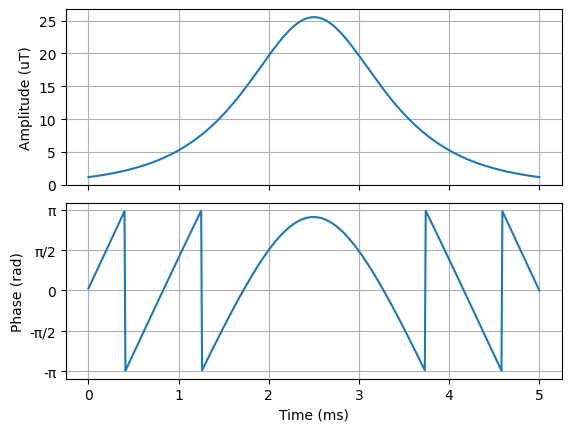

In [72]:
optimal_amplitude = pulse.get_optimal_amplitude(torch.pi)
pulse.amplitude = optimal_amplitude

pulse.display()

Now we set up a non-selective simulation (i.e. no gradients or positions). We first need a range of isochromat frequencies to simulate, which we generate using the linspace command. Then we use the BlochDispatcher class to handle selection of the correct simulation style kernel, such as non-selective versus spatial-spectral, and also on whether a CUDA GPU is available for GPU acceleration. If this is not the case, the dispatcher will default to a highly parallel CPU-based simulation using numba. Finally, it is possible to suppress the output of the dispatcher by setting the verbose flag to False.

We then run the simulation after setting our pulse and isochromat frequencies. In the run method of the dispatcher, we set the relaxation times to infinity and pass the time step. It is also possible to set the initial magnetisation or force the simulation to run on the CPU, which is valuable for smaller problems where the transfer of data to the GPU can impose a large overhead on execution speed.

In [6]:
num_df = 2001
df = torch.linspace(-4000, 4000, num_df)
    
dispatcher = BlochDispatcher()
dispatcher.set_rf(pulse)
dispatcher.set_df(df)

magnetisation = dispatcher.simulate(t1=torch.inf, t2=torch.inf, dt=dt)

SimulationStyle.NON_SELECTIVE took 0.202 seconds for 2001 isochromats undergoing 502 time steps using GPU. Total iterations = 1004502, iters/s = 4977505.88


All simulation results from the dispatcher are wrapped in a class, allowing for easy access to common quantities. 

In [7]:
mx = magnetisation.mx
my = magnetisation.my
mxy = magnetisation.mxy
mxy_phase = magnetisation.mxy_phase
mz = magnetisation.mz
inversion_efficiency = magnetisation.inversion_efficiency

We now visualise the frequency profile of the hyperbolic secant pulse by looking at the last time step.

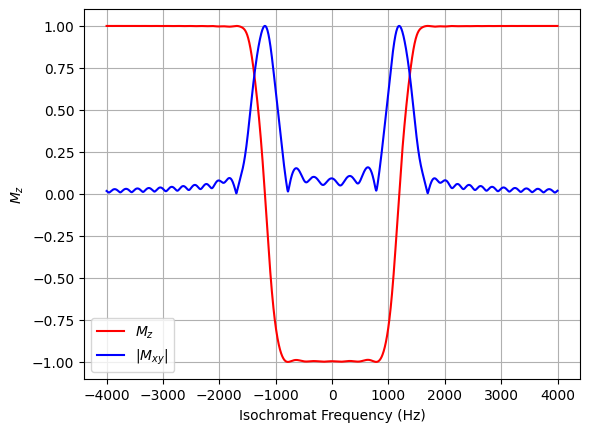

In [14]:
plt.plot(df, mz[..., -1], color='r', label='$M_z$')
plt.plot(df, mxy[..., -1], color='b', label='$|M_{xy}|$')
plt.xlabel('Isochromat Frequency (Hz)')
plt.ylabel('$M_z$')
plt.grid()
plt.legend()
plt.show()

Alternatively, if you know what simulation kernel you'd like to use, and would like to avoid the overhead of the dispatcher, you can call the method of choice directly, as shown below. Note that CPU methods require numpy arrays, whilst the GPU methods require torch Tensors. This conversion is handled for you automatically by the dispatcher. Another difference is that the dispatcher provides a wrapper around the magnetisation called the Magnetisation class, whilst the methods themselves return a numpy array (CPU) or torch Tensor (GPU).

In [5]:
import simulate
if torch.cuda.is_available():
    magnetisation_direct = simulate.kernels.gpu_non_selective(t1=torch.inf, t2=torch.inf, dt=dt, df=df,         rf=pulse.waveform,         initial_magnetisation=torch.tensor([0., 0., 1.]))
else:
    magnetisation_direct = simulate.kernels.cpu_non_selective(t1=np.inf,    t2=np.inf,    dt=dt, df=df.numpy(), rf=pulse.waveform.numpy(), initial_magnetisation=np.array([0., 0., 1.]))
    
print(magnetisation_direct.shape)
plt.plot(df, mz[..., -1], color='r', label='$M_z$')
plt.plot(df, mxy[..., -1], color='b', label='$|M_{xy}|$')
plt.xlabel('Isochromat Frequency (Hz)')
plt.ylabel('$M_z$')
plt.grid()
plt.legend()
plt.show()

NameError: name 'df' is not defined